# PENGELOMPOKKAN DATA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
file_path = "student_lifestyle_100k.csv"
df = pd.read_csv(r"C:\Users\Michael Marcel\OneDrive\Desktop\TA\Data\Dataset\student_lifestyle_100k.csv")

In [4]:
df['Gender'].value_counts()

Gender
Male      50120
Female    49880
Name: count, dtype: int64

In [5]:
df['Department'].value_counts()

Department
Science        20071
Engineering    20057
Arts           19998
Medical        19964
Business       19910
Name: count, dtype: int64

## Pengelompokkan Data berdasarkan Department

- Student per department

In [74]:
df.groupby('Department')['Student_ID'].count().reset_index()

,Department,Student_ID
0,Arts,19998
1,Business,19910
2,Engineering,20057
3,Medical,19964
4,Science,20071


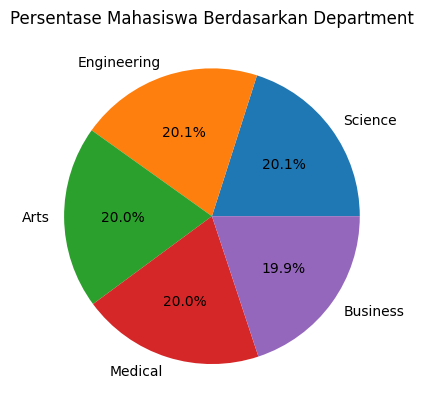

In [75]:
dept = df['Department'].value_counts()

plt.pie(dept, labels=dept.index, autopct='%1.1f%%')
plt.title("Persentase Mahasiswa Berdasarkan Department")
plt.show()

- Gender per Department

In [76]:
pd.crosstab(df['Department'], df['Gender'], margins=True)

Gender,Female,Male,All
Department,,,
Arts,10007,9991,19998
Business,9936,9974,19910
Engineering,9958,10099,20057
Medical,9880,10084,19964
Science,10099,9972,20071
All,49880,50120,100000


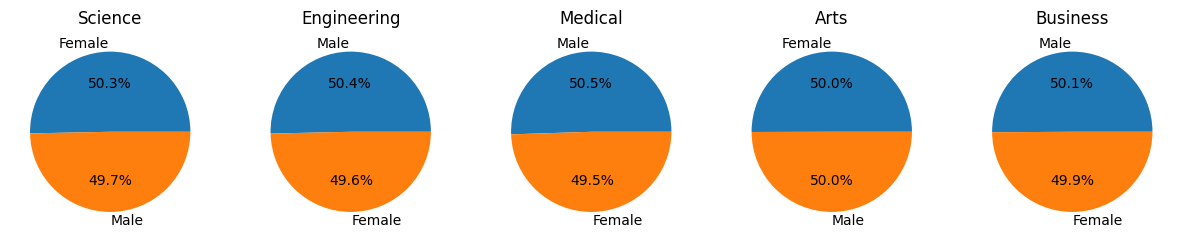

In [77]:
dept_list = df['Department'].unique()

fig, axes = plt.subplots(1, len(dept_list), figsize=(15,5))

for i, dept in enumerate(dept_list):
    data = df[df['Department'] == dept]['Gender'].value_counts()
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%')
    axes[i].set_title(dept)

plt.show()

- CGPA per Department

In [78]:
df.groupby('Department')['CGPA'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Department,mean,median,min,max
0,Arts,2.902723,2.9,1.72,4.0
1,Business,2.897674,2.9,1.56,4.0
2,Engineering,2.897135,2.9,1.59,4.0
3,Medical,2.896052,2.9,1.65,4.0
4,Science,2.897992,2.9,1.68,4.0


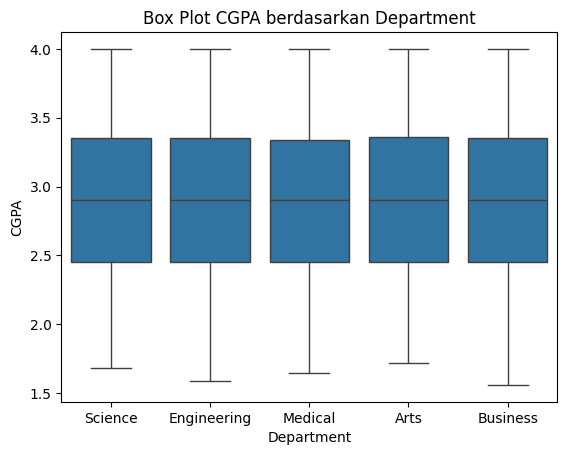

In [79]:
sns.boxplot(x='Department', y='CGPA', data=df)
plt.title("Box Plot CGPA berdasarkan Department")
plt.show()

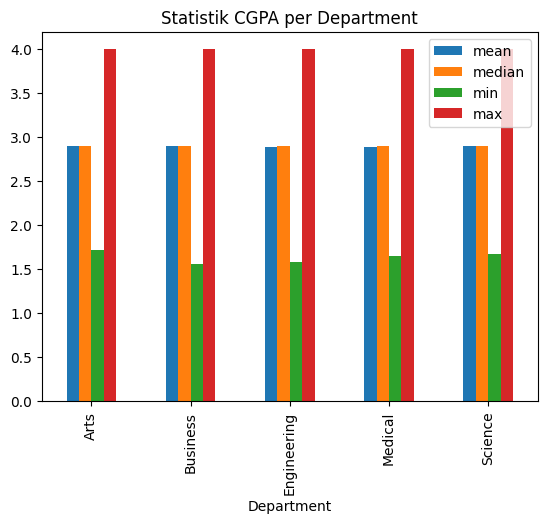

In [80]:
depart_CGPA_stats = df.groupby('Department')['CGPA'].agg(['mean', 'median', 'min', 'max'])

depart_CGPA_stats.plot(kind='bar')
plt.title("Statistik CGPA per Department")
plt.show()

Nilai CGPA menunjukkan perbedaan performa akademik antar department. Nilai CGPA antar department menunjukkan distribusi yang merata/seragam. Median dari nilai CGPA berdasarkan Department adalah 2.9. Berdasarkan nilai mean, department Arts memiliki rata-rata CGPA tertinggi yaitu 2.9027, sedangkan yang terendah terdapat pada Medical yaitu 2.8961. Berdasarkan nilai min, nilai terendah terdapat pada Business yaitu 1.56, sedangkan min tertinggi terdapat pada Arts yaitu 1.72. Untuk nilai max, seluruh department memiliki nilai yang sama yaitu 4.0.

- Sleep Duration per Department

In [81]:
df.groupby('Department')['Sleep_Duration'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Department,mean,median,min,max
0,Arts,6.998810,7.0,3.0,12.0
1,Business,6.991577,7.0,3.0,12.0
2,Engineering,6.990756,7.0,3.0,12.0
3,Medical,7.002715,7.0,3.0,12.0
4,Science,6.998266,7.0,3.0,12.0


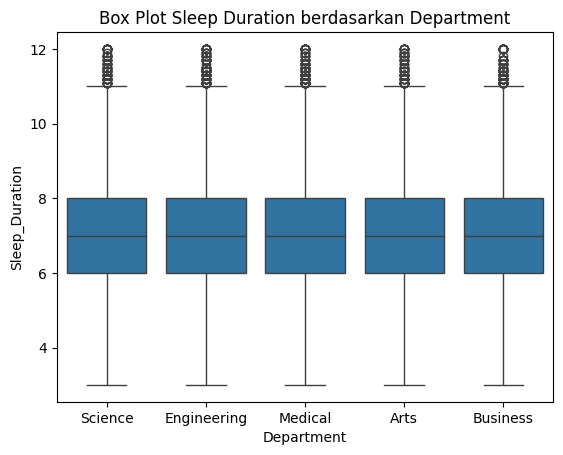

In [82]:
sns.boxplot(x='Department', y='Sleep_Duration', data=df)
plt.title("Box Plot Sleep Duration berdasarkan Department")
plt.show()

In [83]:
data = df["Sleep_Duration"]

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(data < lower_bound) | (data > upper_bound)]

print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)
print("Jumlah outlier:", len(outliers))

Batas bawah: 3.0
Batas atas: 11.0
Jumlah outlier: 369


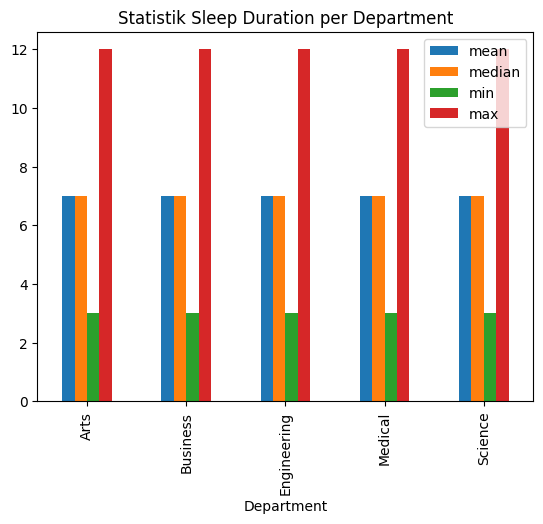

In [84]:
depart_sleep_stats = df.groupby('Department')['Sleep_Duration'].agg(['mean', 'median', 'min', 'max'])

depart_sleep_stats.plot(kind='bar')
plt.title("Statistik Sleep Duration per Department")
plt.show()

Durasi tidur mahasiswa menunjukkan distribusi yang merata/seragam dan memiliki perbedaan yang sangat kecil. Median dari Study_Hours berdasarkan Department adalah 4.5. Pada variabel durasi tidur, nilai mean tertinggi terdapat pada Medical yaitu 7.0027 jam, sedangkan yang terendah terdapat pada Arts yaitu sekitar 6.99 jam. Nilai min pada seluruh department sama yaitu 3 jam, sementara nilai max juga sama yaitu 12 jam.

- Study Hours per Department

In [85]:
df.groupby('Department')['Study_Hours'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Department,mean,median,min,max
0,Arts,4.504655,4.5,0.0,11.9
1,Business,4.553430,4.6,0.0,12.6
2,Engineering,4.481209,4.5,0.0,12.3
3,Medical,4.501688,4.5,0.0,12.1
4,Science,4.506876,4.5,0.0,12.8


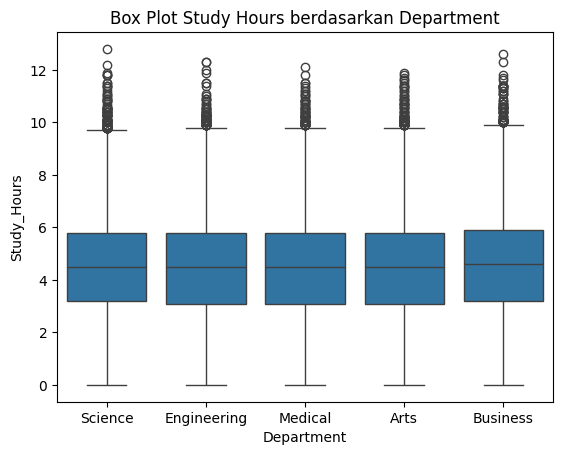

In [86]:
sns.boxplot(x='Department', y='Study_Hours', data=df)
plt.title("Box Plot Study Hours berdasarkan Department")
plt.show()

In [87]:
data = df["Study_Hours"]

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(data < lower_bound) | (data > upper_bound)]

print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)
print("Jumlah outlier:", len(outliers))

Batas bawah: -0.6999999999999993
Batas atas: 9.7
Jumlah outlier: 432


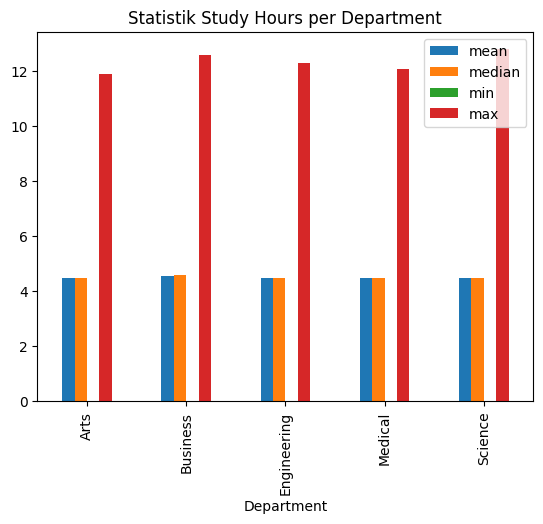

In [88]:
depart_study_stats = df.groupby('Department')['Study_Hours'].agg(['mean', 'median', 'min', 'max'])

depart_study_stats.plot(kind='bar')
plt.title("Statistik Study Hours per Department")
plt.show()

Durasi belajar mahasiswa juga menunjukkan distribusi yang merata/seragam dan memiliki perbedaan yang sangat kecil. Nilai mean tertinggi terdapat pada Business yaitu 4.5534 jam, sedangkan yang terendah terdapat pada Engineering yaitu 4.4812 jam. Berdasarkan nilai min, seluruh department memiliki nilai terendah yang sama yaitu 0 jam. Untuk nilai max, nilai tertinggi terdapat pada Business yaitu 12.8 jam, sedangkan max terendah terdapat pada Engineering yaitu sekitar 12 jam.

- Social Media Hours per Department

In [89]:
df.groupby('Department')['Social_Media_Hours'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Department,mean,median,min,max
0,Arts,3.498940,3.5,0.0,10.0
1,Business,3.497529,3.5,0.0,10.0
2,Engineering,3.507075,3.5,0.0,9.8
3,Medical,3.506186,3.5,0.0,9.4
4,Science,3.506666,3.5,0.0,8.8


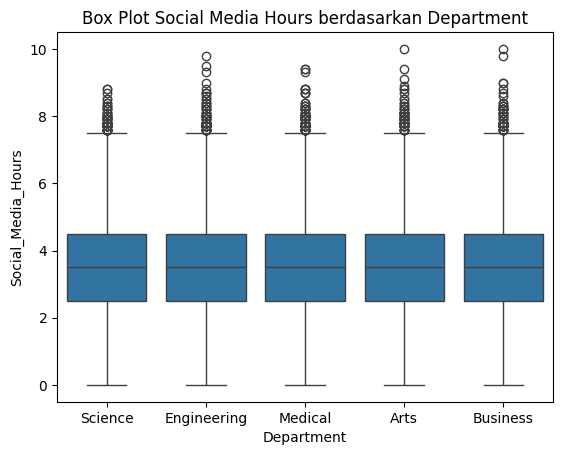

In [90]:
sns.boxplot(x='Department', y='Social_Media_Hours', data=df)
plt.title("Box Plot Social Media Hours berdasarkan Department")
plt.show()

In [91]:
data = df["Social_Media_Hours"]

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(data < lower_bound) | (data > upper_bound)]

print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)
print("Jumlah outlier:", len(outliers))

Batas bawah: -0.5
Batas atas: 7.5
Jumlah outlier: 328


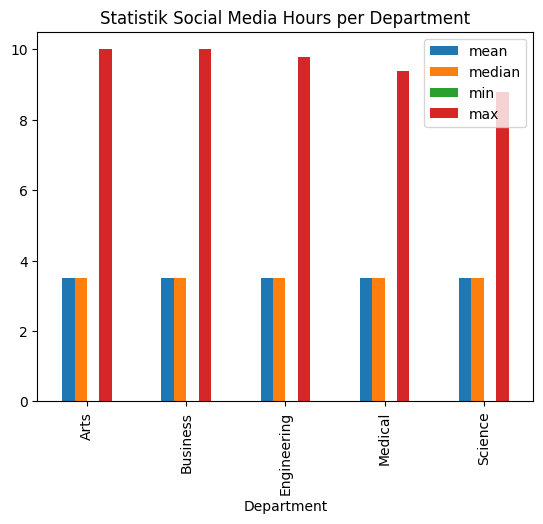

In [92]:
depart_socmed_stats = df.groupby('Department')['Social_Media_Hours'].agg(['mean', 'median', 'min', 'max'])

depart_socmed_stats.plot(kind='bar')
plt.title("Statistik Social Media Hours per Department")
plt.show()

Penggunaan media sosial mahasiswa juga menunjukkan distribusi yang merata/seragam dan memiliki perbedaan yang sangat kecil. Berdasarkan mean, penggunaan media sosial tertinggi terdapat pada Engineering yaitu 3.5071 jam, sedangkan terendah terdapat pada Business yaitu 3.4975 jam. Nilai min pada seluruh department adalah 0 jam. Untuk nilai max, nilai tertinggi terdapat pada Engineering yaitu sekitar 10 jam, sedangkan max terendah terdapat pada Business yaitu sekitar 9 jam.

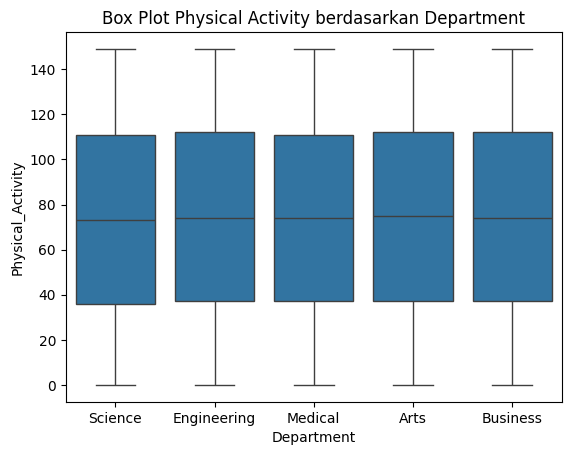

In [6]:
sns.boxplot(x='Department', y='Physical_Activity', data=df)
plt.title("Box Plot Physical Activity berdasarkan Department")
plt.show()

- Depression per Department

In [93]:
pd.crosstab(df['Department'], df['Depression'])

Depression,False,True
Department,,
Arts,17968,2030
Business,17882,2028
Engineering,18037,2020
Medical,17977,1987
Science,18074,1997


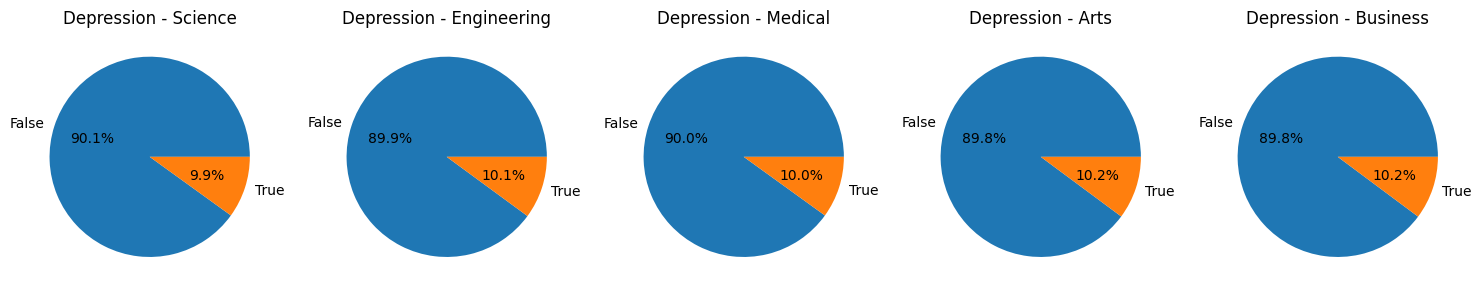

In [94]:
depress_departs = df['Department'].unique()

fig, axes = plt.subplots(1, len(depress_departs), figsize=(15,5))

for i, dept in enumerate(depress_departs):
    data = df[df['Department'] == dept]['Depression'].value_counts()
    
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%')
    axes[i].set_title(f"Depression - {dept}")

plt.tight_layout()
plt.show()

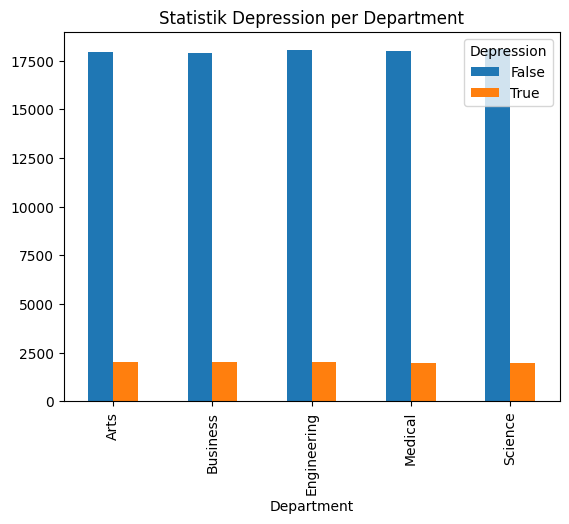

In [95]:
depart_depress_stats = pd.crosstab(df['Department'], df['Depression'])

depart_depress_stats.plot(kind='bar')
plt.title("Statistik Depression per Department")
plt.show()

Distribusi mahasiswa yang mengalami depresi relatif seimbang di setiap department. Jumlah mahasiswa yang mengalami depresi tertinggi terdapat pada department Arts yaitu 2030 mahasiswa, sedangkan jumlah terendah terdapat pada department Medical yaitu 1987 mahasiswa. Berdasarkan persentase mahasiswa yang mengalami depresi, department Arts dan Business memiliki persentase tertinggi, yaitu 10,2% dari total mahasiswa pada department tersebut. Sebaliknya, department Science memiliki persentase terendah, yaitu sekitar 9.9%.

## Pengelompokkan Data Berdasarkan Gender

- Student per Gender

In [96]:
df.groupby('Gender')['Student_ID'].count().reset_index()

,Gender,Student_ID
0,Female,49880
1,Male,50120


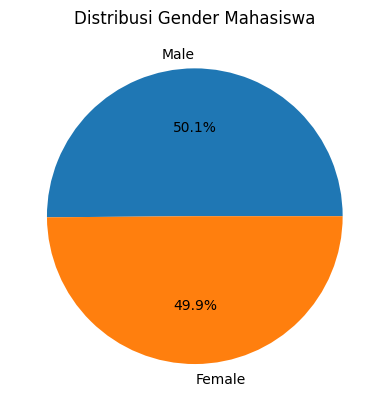

In [97]:
gender = df['Gender'].value_counts()

plt.pie(gender, labels=gender.index, autopct='%1.1f%%')
plt.title("Distribusi Gender Mahasiswa")
plt.show()

- CGPA per Gender

In [98]:
df.groupby('Gender')['CGPA'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Gender,mean,median,min,max
0,Female,2.901070,2.9,1.59,4.0
1,Male,2.895574,2.9,1.56,4.0


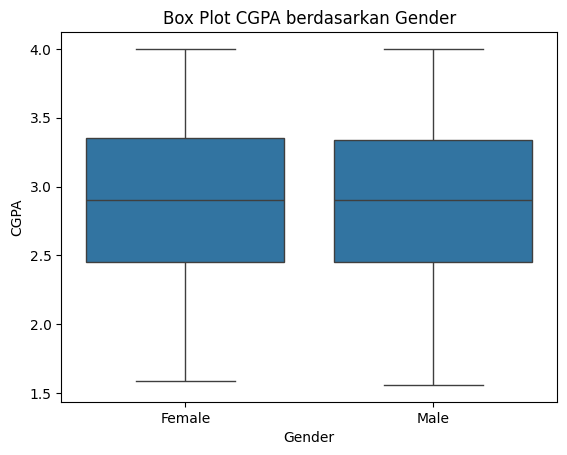

In [99]:
sns.boxplot(x='Gender', y='CGPA', data=df)
plt.title("Box Plot CGPA berdasarkan Gender")
plt.show()

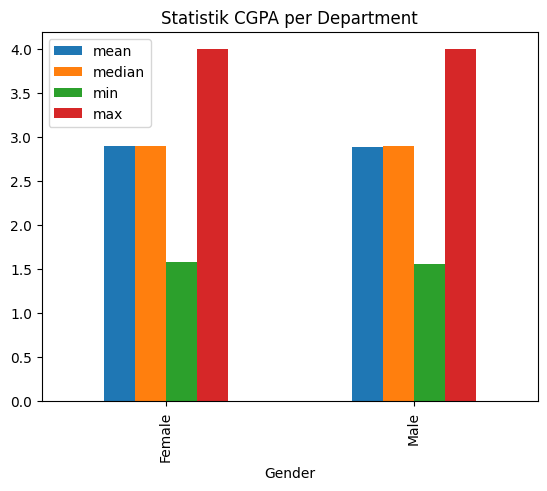

In [100]:
gend_CGPA_stats = df.groupby('Gender')['CGPA'].agg(['mean', 'median', 'min', 'max'])

gend_CGPA_stats.plot(kind='bar')
plt.title("Statistik CGPA per Department")
plt.show()

Berdasarkan nilai mean, mahasiswa Female memiliki rata-rata CGPA sedikit lebih tinggi yaitu sekitar 2.9, sedangkan mahasiswa Male memiliki mean sedikit lebih rendah yaitu sekitar 2.8. Berdasarkan nilai min, nilai terendah terdapat pada Male yaitu sekitar 1.56, sedangkan Female memiliki min sedikit lebih tinggi yaotu 1.59. Untuk nilai max, kedua gender memiliki nilai yang sama yaitu 4.0.

- Sleep Duration per Gender

In [101]:
df.groupby('Gender')['Sleep_Duration'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Gender,mean,median,min,max
0,Female,6.992662,7.0,3.0,12.0
1,Male,7.000170,7.0,3.0,12.0


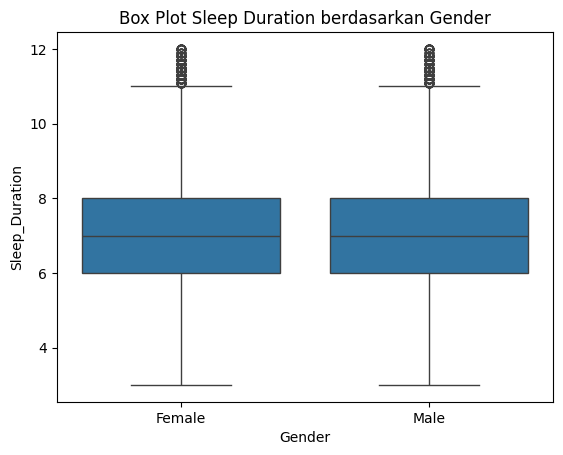

In [102]:
sns.boxplot(x='Gender', y='Sleep_Duration', data=df)
plt.title("Box Plot Sleep Duration berdasarkan Gender")
plt.show()

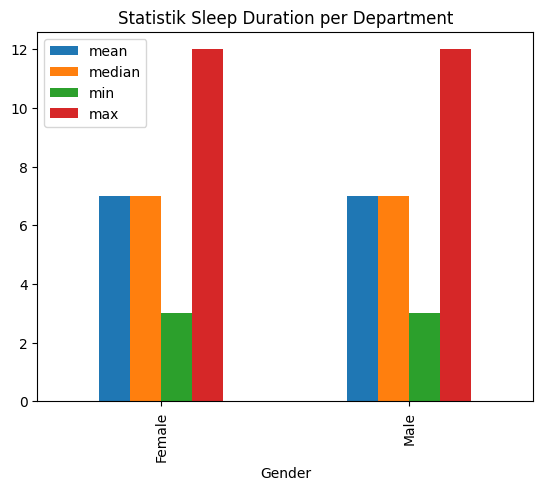

In [103]:
gend_sleep_stats = df.groupby('Gender')['Sleep_Duration'].agg(['mean', 'median', 'min', 'max'])

gend_sleep_stats.plot(kind='bar')
plt.title("Statistik Sleep Duration per Department")
plt.show()

Durasi tidur mahasiswa menunjukkan perbedaan yang sangat kecil antar gender. Mahasiswa Male memiliki mean durasi tidur sedikit lebih tinggi yaitu sekitar 7.00 jam, sedangkan Female sekitar 6.99 jam. Nilai min pada kedua gender adalah sekitar 3 jam, sementara nilai max mencapai sekitar 12 jam, yang menunjukkan pola tidur yang relatif serupa.

- Study Hours per Gender

In [104]:
df.groupby('Gender')['Study_Hours'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Gender,mean,median,min,max
0,Female,4.508248,4.5,0.0,12.8
1,Male,4.510780,4.5,0.0,12.6


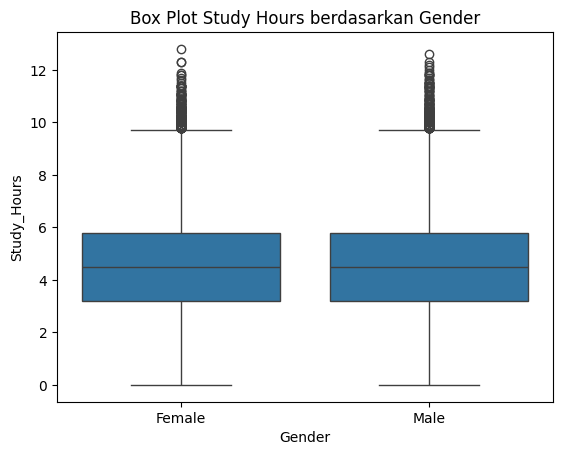

In [105]:
sns.boxplot(x='Gender', y='Study_Hours', data=df)
plt.title("Box Plot Study Hours berdasarkan Gender")
plt.show()

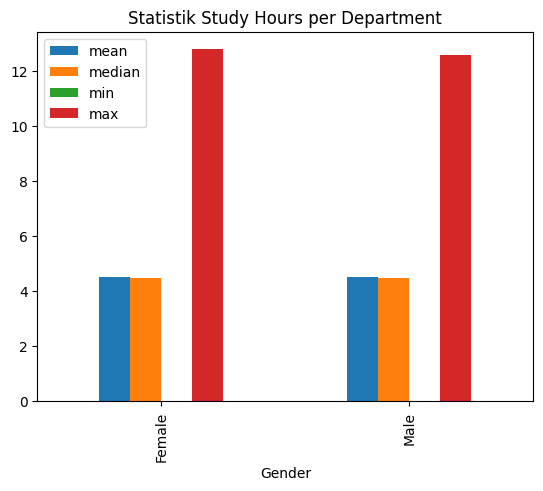

In [106]:
gend_study_stats = df.groupby('Gender')['Study_Hours'].agg(['mean', 'median', 'min', 'max'])

gend_study_stats.plot(kind='bar')
plt.title("Statistik Study Hours per Department")
plt.show()

Pada variabel jam belajar, mahasiswa Male memiliki mean sedikit lebih tinggi yaitu sekitar 4.51 jam, sedangkan Female sekitar 4.50 jam. Nilai minimum pada kedua gender adalah 0 jam, sedangkan nilai max tertinggi ada pada male mencapai sekitar 12.8 jam.

- Social Media Hours per Gender

In [107]:
df.groupby('Gender')['Social_Media_Hours'].agg(['mean', 'median', 'min', 'max']).reset_index()

,Gender,mean,median,min,max
0,Female,3.501093,3.5,0.0,10.0
1,Male,3.505473,3.5,0.0,10.0


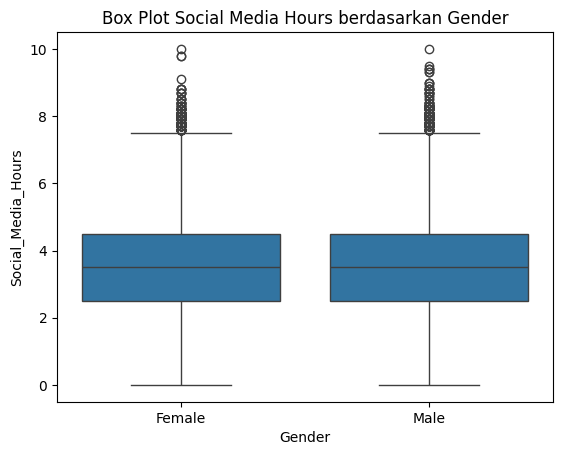

In [108]:
sns.boxplot(x='Gender', y='Social_Media_Hours', data=df)
plt.title("Box Plot Social Media Hours berdasarkan Gender")
plt.show()

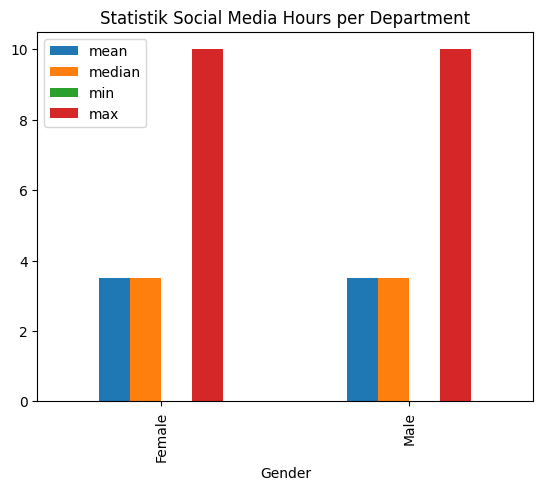

In [109]:
gend_socmed_stats = df.groupby('Gender')['Social_Media_Hours'].agg(['mean', 'median', 'min', 'max'])

gend_socmed_stats.plot(kind='bar')
plt.title("Statistik Social Media Hours per Department")
plt.show()

Penggunaan media sosial antara kedua gender juga relatif seimbang. Mahasiswa Male memiliki mean penggunaan media sosial sedikit lebih tinggi yaitu sekitar 3.50 jam, sedangkan Female sedikit lebih rendah. Nilai min pada kedua gender adalah 0 jam, sementara nilai max mencapai sekitar 10 jam.

- Depression per Gender

In [110]:
pd.crosstab(df['Gender'], df['Depression'])

Depression,False,True
Gender,,
Female,44929,4951
Male,45009,5111


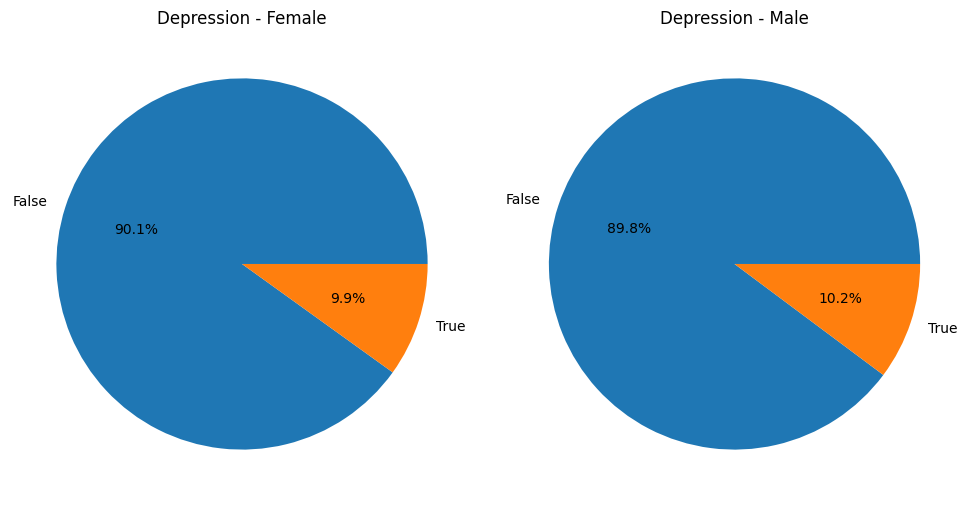

In [111]:
depress_gends = df['Gender'].unique()

fig, axes = plt.subplots(1, len(depress_gends), figsize=(10,5))

for i, gender in enumerate(depress_gends):
    data = df[df['Gender'] == gender]['Depression'].value_counts()
    
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%')
    axes[i].set_title(f"Depression - {gender}")

plt.tight_layout()
plt.show()

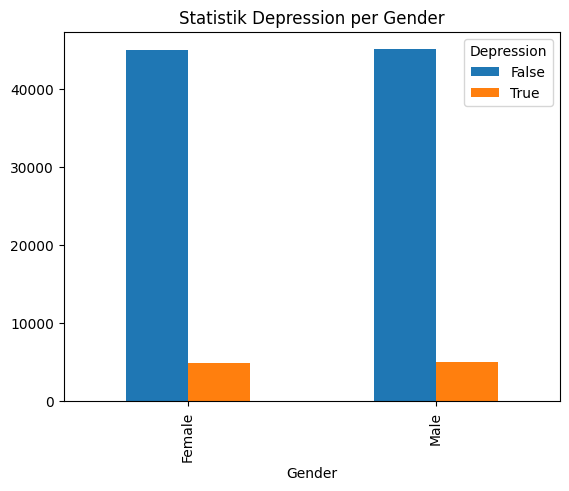

In [112]:
gend_depress_stats = pd.crosstab(df['Gender'], df['Depression'])

gend_depress_stats.plot(kind='bar')
plt.title("Statistik Depression per Gender")
plt.show()

Berdasarkan persentase, mahasiswa yang mengalami depresi pada gender Female sedikit lebih tinggi dibandingkan Male. Jumlah mahasiswa yang mengalami depresi tertinggi terdapat pada gender Male yaitu 5111 mahasiswa, sedangkan jumlah terendah terdapat pada gender Female yaitu sekitar 4951 mahasiswa. Berdasarkan persentase mahasiswa yang mengalami depresi, gender Male memiliki persentase tertinggi, yaitu 10,2% dari total mahasiswa pada gender tersebut. Sebaliknya, gender female memiliki persentase terendah, yaitu sekitar 9.9%.

## Pengelompokkan Data Berdasarkan Depression

- Jumlah mahasiswa pada setiap kategori Depression

In [113]:
df.groupby('Depression')['Student_ID'].count().reset_index()

,Depression,Student_ID
0,False,89938
1,True,10062


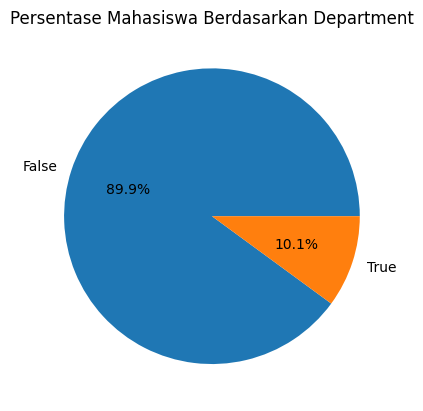

In [114]:
dept = df['Depression'].value_counts()

plt.pie(dept, labels=dept.index, autopct='%1.1f%%')
plt.title("Persentase Mahasiswa Berdasarkan Department")
plt.show()

- Depression by Sleep_Duration

In [115]:
df.groupby('Depression')['Sleep_Duration'].agg(['mean','median','min','max']).reset_index()

,Depression,mean,median,min,max
0,False,7.025263,7.0,3.0,12.0
1,True,6.738660,6.8,3.0,12.0


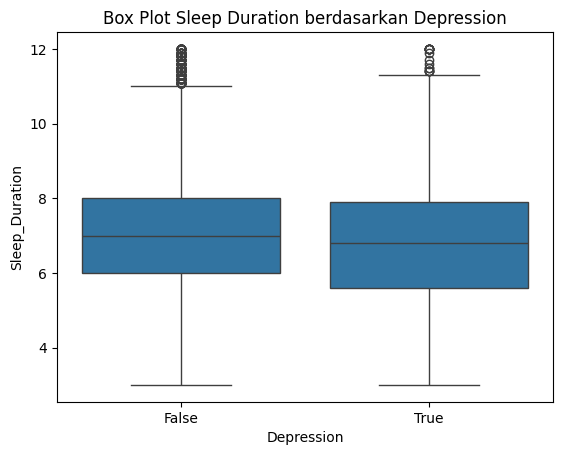

In [116]:
sns.boxplot(x='Depression', y='Sleep_Duration', data=df)
plt.title("Box Plot Sleep Duration berdasarkan Depression")
plt.show()

- Depression by Study_Hours

In [117]:
df.groupby('Depression')['Study_Hours'].agg(['mean','median','min','max']).reset_index()

,Depression,mean,median,min,max
0,False,4.520047,4.5,0.0,12.8
1,True,4.415395,4.4,0.0,12.2


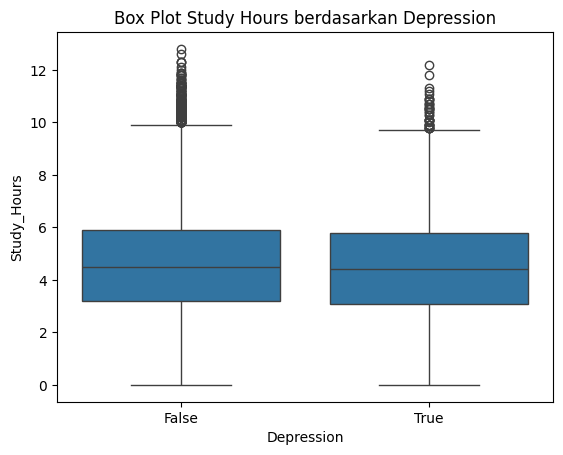

In [118]:
sns.boxplot(x='Depression', y='Study_Hours', data=df)
plt.title("Box Plot Study Hours berdasarkan Depression")
plt.show()

- Depression by Social_Media_Hours

In [119]:
df.groupby('Depression')['Social_Media_Hours'].agg(['mean','median','min','max']).reset_index()

,Depression,mean,median,min,max
0,False,3.494948,3.5,0.0,10.0
1,True,3.577837,3.6,0.0,9.4


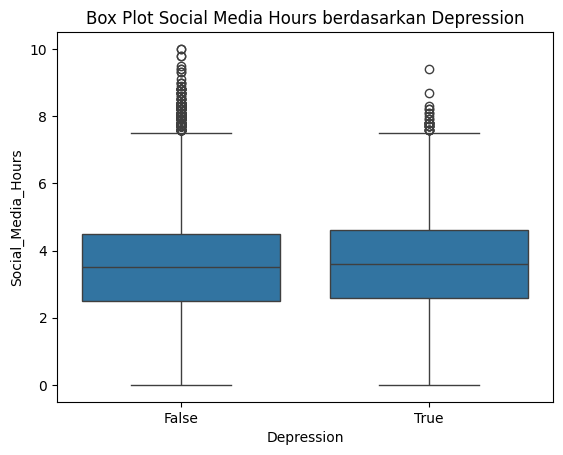

In [120]:
sns.boxplot(x='Depression', y='Social_Media_Hours', data=df)
plt.title("Box Plot Social Media Hours berdasarkan Depression")
plt.show()

- Depression by Physical_Activity

In [121]:
df.groupby('Depression')['Physical_Activity'].agg(['mean','median','min','max']).reset_index()

,Depression,mean,median,min,max
0,False,74.555305,74.0,0,149
1,True,72.546512,71.0,0,149


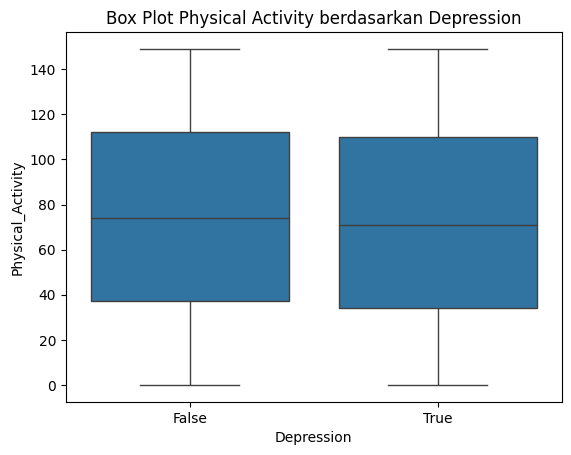

In [122]:
sns.boxplot(x='Depression', y='Physical_Activity', data=df)
plt.title("Box Plot Physical Activity berdasarkan Depression")
plt.show()

- CGPA by Depression and Gender

In [123]:
df.groupby(['Gender','Depression'])['CGPA'].agg(['mean','median','min','max']).reset_index()

,Gender,Depression,mean,median,min,max
0,Female,False,2.931891,2.94,1.59,4.0
1,Female,True,2.621377,2.43,1.69,4.0
2,Male,False,2.928465,2.94,1.56,4.0
3,Male,True,2.605928,2.42,1.72,4.0


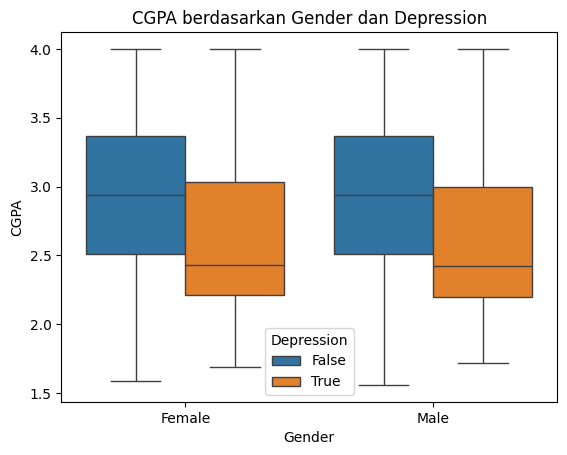

In [124]:
sns.boxplot(x='Gender', y='CGPA', hue='Depression', data=df)

plt.title("CGPA berdasarkan Gender dan Depression")
plt.xlabel("Gender")
plt.ylabel("CGPA")
plt.show()

- Depression by Gender with Sleep_Duration

In [125]:
df.groupby(['Gender','Depression'])['Sleep_Duration'].agg(['mean','median','min','max']).reset_index()

,Gender,Depression,mean,median,min,max
0,Female,False,7.020116,7.0,3.0,12.0
1,Female,True,6.743527,6.8,3.0,12.0
2,Male,False,7.030401,7.0,3.0,12.0
3,Male,True,6.733946,6.8,3.0,12.0


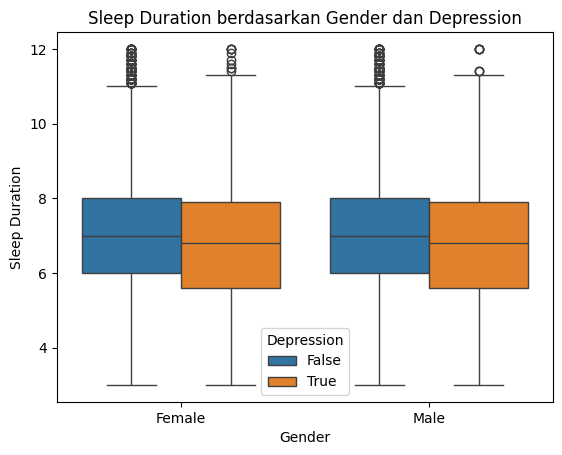

In [126]:
sns.boxplot(x='Gender', y='Sleep_Duration', hue='Depression', data=df)

plt.title("Sleep Duration berdasarkan Gender dan Depression")
plt.xlabel("Gender")
plt.ylabel("Sleep Duration")
plt.show()

- Study_Hours by Gender Depression

In [127]:
df.groupby(['Gender','Depression'])['Study_Hours'].agg(['mean','median','min','max']).reset_index()

,Gender,Depression,mean,median,min,max
0,Female,False,4.517995,4.5,0.0,12.8
1,Female,True,4.419794,4.5,0.0,11.3
2,Male,False,4.522096,4.5,0.0,12.6
3,Male,True,4.411133,4.4,0.0,12.2


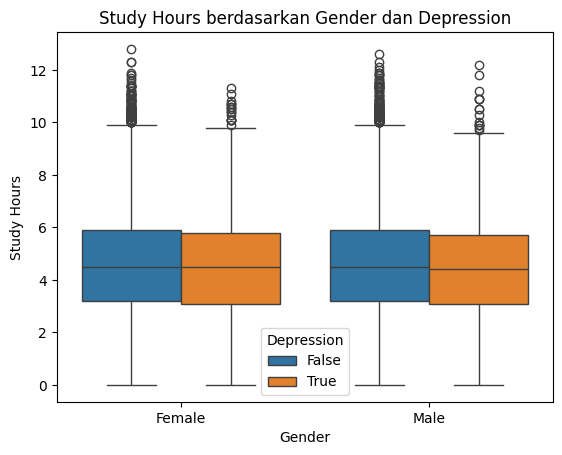

In [128]:
sns.boxplot(x='Gender', y='Study_Hours', hue='Depression', data=df)

plt.title("Study Hours berdasarkan Gender dan Depression")
plt.xlabel("Gender")
plt.ylabel("Study Hours")
plt.show()

- Study_Hours by Depression and Gender

In [129]:
df.groupby(['Gender','Depression'])['Social_Media_Hours'].agg(['mean','median','min','max']).reset_index()

,Gender,Depression,mean,median,min,max
0,Female,False,3.491262,3.5,0.0,10.0
1,Female,True,3.590305,3.6,0.0,8.7
2,Male,False,3.498627,3.5,0.0,10.0
3,Male,True,3.565760,3.5,0.0,9.4


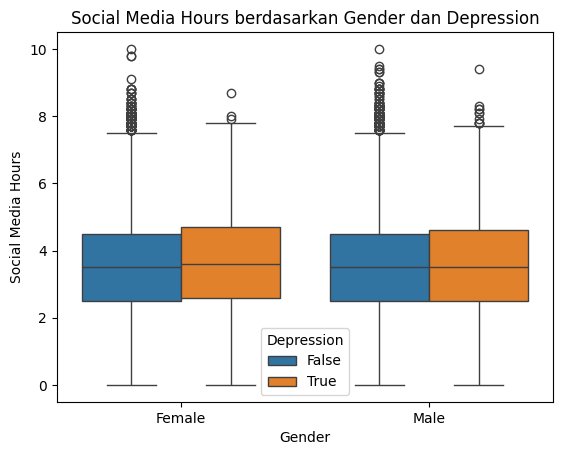

In [130]:
sns.boxplot(x='Gender', y='Social_Media_Hours', hue='Depression', data=df)

plt.title("Social Media Hours berdasarkan Gender dan Depression")
plt.xlabel("Gender")
plt.ylabel("Social Media Hours")
plt.show()

-  Social_Media_Hours by Depression and Gender

In [131]:
df.groupby(['Gender','Depression'])['Physical_Activity'].agg(['mean','median','min','max']).reset_index()

,Gender,Depression,mean,median,min,max
0,Female,False,74.395580,74.0,0,149
1,Female,True,72.103413,72.0,0,149
2,Male,False,74.714746,75.0,0,149
3,Male,True,72.975739,71.0,0,149


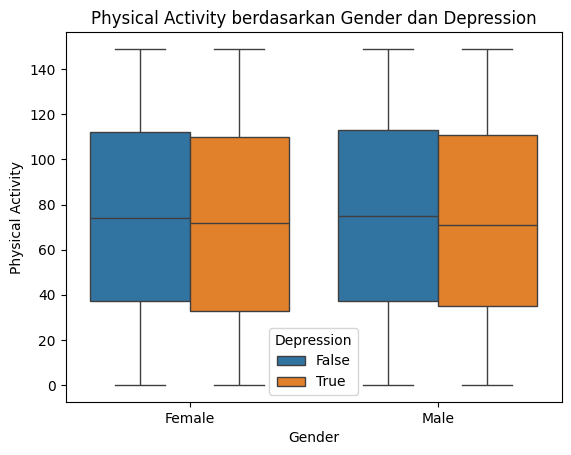

In [132]:
sns.boxplot(x='Gender', y='Physical_Activity', hue='Depression', data=df)

plt.title("Physical Activity berdasarkan Gender dan Depression")
plt.xlabel("Gender")
plt.ylabel("Physical Activity")
plt.show()

-  CGPA by Depression and Department

In [133]:
df.groupby(['Department','Depression'])['CGPA'].agg(['mean','median','min','max']).reset_index()

,Department,Depression,mean,median,min,max
0,Arts,False,2.934243,2.94,1.72,4.0
1,Arts,True,2.623734,2.43,1.75,4.0
2,Business,False,2.930306,2.94,1.56,4.0
3,Business,True,2.609936,2.42,1.71,4.0
4,Engineering,False,2.927316,2.94,1.59,4.0
5,Engineering,True,2.627644,2.44,1.71,4.0
6,Medical,False,2.928584,2.94,1.65,4.0
7,Medical,True,2.601726,2.42,1.73,4.0
8,Science,False,2.930445,2.94,1.68,4.0
9,Science,True,2.604276,2.42,1.69,4.0


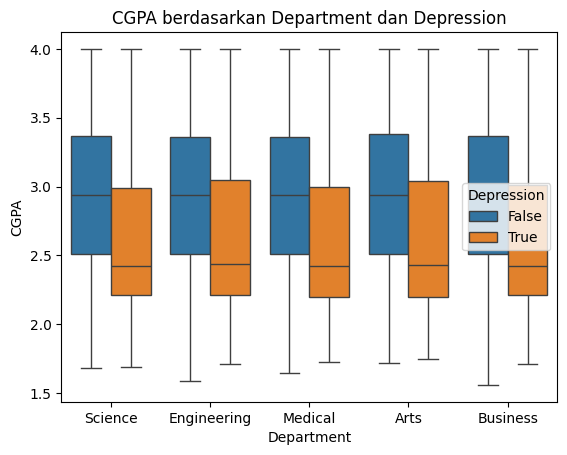

In [134]:
sns.boxplot(x='Department', y='CGPA', hue='Depression', data=df)

plt.title("CGPA berdasarkan Department dan Depression")
plt.xlabel("Department")
plt.ylabel("CGPA")
plt.show()

-  Sleep_Duration by Depression and Department

In [135]:
df.groupby(['Department','Depression'])['Sleep_Duration'].agg(['mean','median','min','max']).reset_index()

,Department,Depression,mean,median,min,max
0,Arts,False,7.029041,7.0,3.0,12.0
1,Arts,True,6.731232,6.8,3.0,11.5
2,Business,False,7.026535,7.0,3.0,12.0
3,Business,True,6.683333,6.8,3.0,11.4
4,Engineering,False,7.016937,7.0,3.0,12.0
5,Engineering,True,6.756980,6.9,3.0,12.0
6,Medical,False,7.030211,7.0,3.0,12.0
7,Medical,True,6.753951,6.8,3.0,12.0
8,Science,False,7.023636,7.0,3.0,12.0
9,Science,True,6.768653,6.8,3.0,12.0


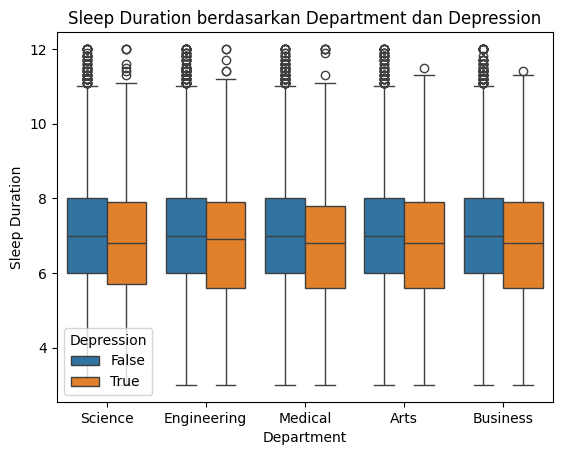

In [136]:
sns.boxplot(x='Department', y='Sleep_Duration', hue='Depression', data=df)

plt.title("Sleep Duration berdasarkan Department dan Depression")
plt.xlabel("Department")
plt.ylabel("Sleep Duration")
plt.show()

-  Study_Hours by Depression and Department

In [137]:
df.groupby(['Department','Depression'])['Study_Hours'].agg(['mean','median','min','max']).reset_index()

,Department,Depression,mean,median,min,max
0,Arts,False,4.515644,4.5,0.0,11.9
1,Arts,True,4.407389,4.4,0.0,11.3
2,Business,False,4.550324,4.5,0.0,12.6
3,Business,True,4.580819,4.6,0.0,11.8
4,Engineering,False,4.494883,4.5,0.0,12.3
5,Engineering,True,4.359109,4.4,0.0,10.5
6,Medical,False,4.521094,4.5,0.0,12.1
7,Medical,True,4.326120,4.4,0.0,10.8
8,Science,False,4.518540,4.5,0.0,12.8
9,Science,True,4.401302,4.4,0.0,12.2


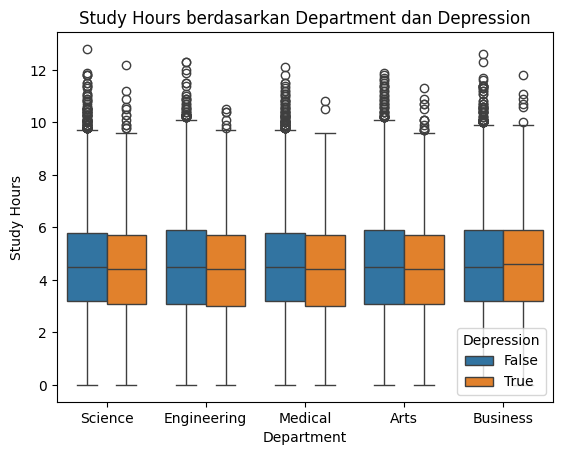

In [138]:
sns.boxplot(x='Department', y='Study_Hours', hue='Depression', data=df)

plt.title("Study Hours berdasarkan Department dan Depression")
plt.xlabel("Department")
plt.ylabel("Study Hours")
plt.show()

-  Social_Media_Hours by Depression and Department

In [139]:
df.groupby(['Department','Depression'])['Social_Media_Hours'].agg(['mean','median','min','max']).reset_index()

,Department,Depression,mean,median,min,max
0,Arts,False,3.487678,3.5,0.0,10.0
1,Arts,True,3.598621,3.6,0.0,8.3
2,Business,False,3.489392,3.5,0.0,10.0
3,Business,True,3.569280,3.6,0.0,8.1
4,Engineering,False,3.497755,3.5,0.0,9.8
5,Engineering,True,3.590297,3.6,0.0,8.7
6,Medical,False,3.500111,3.5,0.0,9.4
7,Medical,True,3.561147,3.5,0.0,9.4
8,Science,False,3.499734,3.5,0.0,8.8
9,Science,True,3.569404,3.5,0.0,8.2


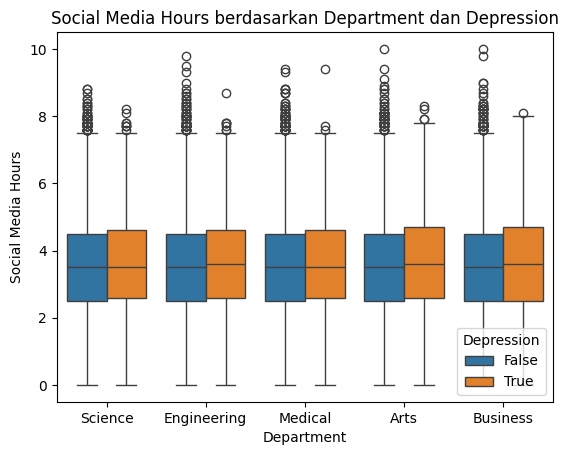

In [140]:
sns.boxplot(x='Department', y='Social_Media_Hours', hue='Depression', data=df)

plt.title("Social Media Hours berdasarkan Department dan Depression")
plt.xlabel("Department")
plt.ylabel("Social Media Hours")
plt.show()

-  Physical_Activity by Depression and Department

In [141]:
df.groupby(['Department','Depression'])['Physical_Activity'].agg(['mean','median','min','max']).reset_index()

,Department,Depression,mean,median,min,max
0,Arts,False,74.945403,75.0,0,149
1,Arts,True,73.514778,73.0,0,149
2,Business,False,74.667375,75.0,0,149
3,Business,True,72.607988,72.0,0,149
4,Engineering,False,74.801852,74.0,0,149
5,Engineering,True,71.274752,70.0,0,149
6,Medical,False,74.284641,74.0,0,149
7,Medical,True,73.452441,74.0,0,149
8,Science,False,74.079783,74.0,0,149
9,Science,True,71.884827,69.0,0,149


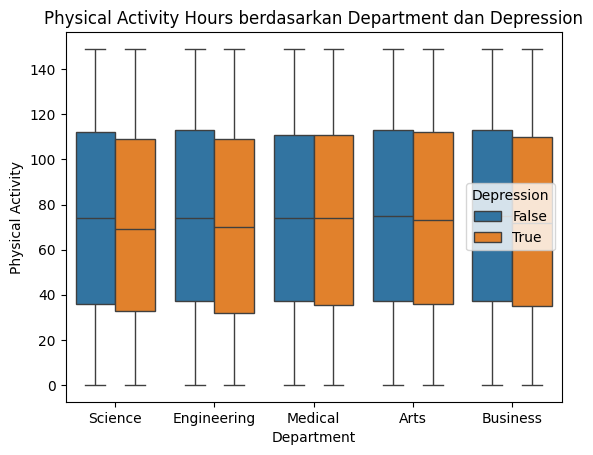

In [142]:
sns.boxplot(x='Department', y='Physical_Activity', hue='Depression', data=df)

plt.title("Physical Activity Hours berdasarkan Department dan Depression")
plt.xlabel("Department")
plt.ylabel("Physical Activity")
plt.show()